<h1>1. Import libraries</h1>

In [1]:
import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

# -----------------------------
# Set random seed for reproducibility
# -----------------------------
seed = 42  # you can choose any number
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

configs = {
    "batch_size": 64,
    "path2Save": "/kaggle/working/char_rnn_best.pt",
    "epochs": 10,
    "lr":1e-3, 
    "seq_len": 100,
    "modelRun": "RNN",
    "hidden_dim": 256,
}

Random seed set to 42
Using cuda device


In [2]:
!git clone https://github.com/MarcellusZhao/Build-GPT-from-scratch

Cloning into 'Build-GPT-from-scratch'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 66 (delta 27), reused 53 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 529.41 KiB | 2.58 MiB/s, done.
Resolving deltas: 100% (27/27), done.


<h1>2. Loading, handling, and preparing dataset</h1>

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "text",
    data_files="/kaggle/working/Build-GPT-from-scratch/data/input.txt"
)
text = "\n".join(dataset['train']['text'])
print("Num Chars. in dataset:", len(text))
print(text[:300])

Generating train split: 0 examples [00:00, ? examples/s]

Num Chars. in dataset: 1115393
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [4]:
chars = sorted(list(set(text)))
print(chars)
vocab_size = len(chars)

char_encode = {ch: i for i, ch in enumerate(chars)}
rev_char_encode = {i: ch for ch, i in char_encode.items()}

print(f"\nchar_encode: {char_encode}")

print(f"\nrev_char_encode: {rev_char_encode}")

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

char_encode: {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}

rev_char_encode: {0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-'

In [5]:
fall_back = char_encode.get(" ", 0)
print(fall_back)
def encode(s: str) -> torch.tensor:
    return torch.tensor([char_encode.get(ch, fall_back) for ch in s], dtype=torch.long)
    
def decode(ids) -> str:
    return "".join([rev_char_encode[int(i)] for i in ids])

print(text[0])
data = encode(text)
print("Encoded data shape: ", data[0])
dataAfterDecoder = decode(data)
print("Decoder data shape: ", dataAfterDecoder[0])

1
F
Encoded data shape:  tensor(18)
Decoder data shape:  F


In [6]:
N = len(data)

train_end = int(0.9 * N)
val_end = int(0.95 * N)

train_ids = data[:train_end]
val_ids = data[train_end:val_end]
test_ids = data[val_end:]

print(len(train_ids), len(val_ids), len(test_ids))

1003853 55770 55770


In [7]:
def batch(data: torch.Tensor, batch_size: int) -> torch.Tensor:
    n_batches = data.size(0) // batch_size
    data = data[:n_batches * batch_size]
    return data.view(batch_size, -1)

In [8]:
train_data = batch(train_ids, configs['batch_size']).to(device)
val_data = batch(val_ids, configs['batch_size']).to(device)
test_data = batch(test_ids, configs['batch_size']).to(device)

print(train_data.shape)

torch.Size([64, 15685])


In [9]:
def get_batch(data: torch.Tensor, i: int, seq_len: int):
    seq_len = min(seq_len, data.size(1) - 1 - i)
    X = data[:, i:i+seq_len]
    Y = data[:, i+1:i+seq_len+1]
    return X, Y

<h1>3. Creating Model</h1>

In [10]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        
        # QK^T / sqrt(dk)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        
        # 🔥 Causal Mask
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))
        
        weights = torch.softmax(scores, dim=-1)
        
        output = torch.matmul(weights, V)
        
        return output, weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        
        self.attention = ScaledDotProductAttention()
        
        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, d_model = x.shape
        
        # Linear projections
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        # Split heads → [B, heads, T, d_k]
        Q = Q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        
        # Apply attention
        out, attn = self.attention(Q, K, V, mask)
        
        # Concatenate heads
        out = out.transpose(1, 2).contiguous().view(B, T, d_model)
        
        out = self.fc_out(out)
        
        return out, attn

class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model)

    def forward(self, x, mask=None):
        
        # Attention block
        attn_out, attn_weights  = self.attn(self.ln1(x), mask)
        x = x + attn_out
        
        # Feedforward block
        ffn_out = self.ffn(self.ln2(x))
        x = x + ffn_out
        
        return x, attn_weights 

class PositionalEncoding(nn.Module):
    def __init__(self, hidden_dim, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, hidden_dim)
        position = torch.arange(0, max_len).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0, hidden_dim, 2) * (-math.log(10000.0) / hidden_dim)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.pe = pe.unsqueeze(0)  # [1, T, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


def generate_causal_mask(seq_len, device):
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask.to(device)

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_dim=256, n_heads=4, n_layers=2):
        super().__init__()
        
        self.token_emb = nn.Embedding(vocab_size, hidden_dim)
        self.pos_enc = PositionalEncoding(hidden_dim)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_dim, n_heads)
            for _ in range(n_layers)
        ])
        
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
    
        B, T = x.shape
        mask = generate_causal_mask(T, x.device)
        
        x = self.token_emb(x)
        x = self.pos_enc(x)
        
        attn_maps = []  # store all layers
        
        for block in self.blocks:
            x, attn = block(x, mask)
            attn_maps.append(attn)
        
        logits = self.fc_out(x)
        
        return logits, attn_maps

In [11]:
model = DecoderOnlyTransformer(vocab_size=vocab_size, hidden_dim = configs['hidden_dim']).to(device)

<h1>4. Preparing for training</h1>

In [12]:
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=configs['lr'])

In [13]:
def train_one_epoch(model, data, optimizer, loss_fn, seq_len=128, clip_grad=1.0, device="cpu"):
    
    model.train()
    grad_norms = []
    total_loss = 0.0
    count = 0
    
    data = data.to(device)
    B, T_total = data.shape
    
    for i in tqdm(range(0, T_total - seq_len - 1, seq_len),
                  total=((T_total - seq_len - 1) // seq_len),
                  leave=True, colour="blue", desc="Processing sequences"):
        
        x = data[:, i : i + seq_len].to(device)
        y = data[:, i + 1 : i + seq_len + 1].to(device)
        
        # ✅ Transformer forward (NO hidden state)
        logits, _ = model(x)
        
        B, T, V = logits.shape
        logits = logits.reshape(B * T, V)
        y = y.reshape(B * T)
        
        loss = loss_fn(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        
        # ✅ Gradient norm logging
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        grad_norms.append(grad_norm.item())
        
        optimizer.step()
        
        total_loss += loss.item()
        count += 1
    
    avg_loss = total_loss / count
    avg_grad_norm = sum(grad_norms) / len(grad_norms)
    
    return avg_loss, avg_grad_norm

@torch.inference_mode()
def evaluate(model, data, loss_fn, device="cpu", seq_len=128):
    
    model.eval()
    
    total_loss = 0.0
    count = 0
    
    data = data.to(device)
    B, T_total = data.shape
    
    for i in tqdm(range(0, T_total - seq_len - 1, seq_len),
                  total=((T_total - seq_len - 1) // seq_len),
                  leave=True, colour="green", desc="Processing sequences"):
        
        x = data[:, i : i + seq_len].to(device)
        y = data[:, i + 1 : i + seq_len + 1].to(device)
        
        logits, _ = model(x)  # ✅ no hidden
        
        B, T, V = logits.shape
        logits = logits.reshape(B * T, V)
        y = y.reshape(B * T)
        
        loss = loss_fn(logits, y)
        
        total_loss += loss.item()
        count += 1
    
    return total_loss / count

def train_model(model, train_data, val_data, optimizer, loss_fn,
                epochs=10, lr = 1e-3, seq_len=128, device="cpu"):
    
    model = model.to(device)
    
    train_losses = []
    val_losses = []
    time_each_epoch = []
    
    best_val_loss = float("inf")
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        print(f"\nEpoch {epoch}: ", end="")
        
        train_loss, avg_grad_norm = train_one_epoch(
            model, train_data, optimizer, loss_fn,
            seq_len=seq_len, device=device
        )
        
        val_loss = evaluate(
            model, val_data, loss_fn,
            seq_len=seq_len, device=device
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # ✅ Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_transformer.pth")
            print("✅ Saved best model!", end=" ")
        
        end_time = time.time()
        time_each_epoch.append(end_time - start_time)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | GradNorm: {avg_grad_norm:.4f} || duration: {time_each_epoch[-1]:.4f}")
    
    return train_losses, val_losses, time_each_epoch

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_losses, val_losses, time_each_epoch = train_model(
    model,
    train_data,
    val_data,
    optimizer = optim,
    loss_fn = loss_fn,
    epochs=configs['epochs'],
    lr=configs['lr'],
    seq_len=configs['seq_len'],
    device=device
)


Epoch 1: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Saved best model! Train Loss: 2.3280 | Val Loss: 2.0804 | GradNorm: 0.8826 || duration: 3.3693

Epoch 2: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

...

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Saved best model! Train Loss: 1.3789 | Val Loss: 1.5861 | GradNorm: 0.5871 || duration: 2.7612

Epoch 10: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 1.3579 | Val Loss: 1.5937 | GradNorm: 0.5965 || duration: 2.7476


<h1>5. Evaluation after train</h1>

In [15]:
print(f"progress_train_loss: {train_losses}\n") 
print(f"progress_val_loss: {val_losses}\n") 

print(f"Total time = {sum(time_each_epoch):.2f}s   ||   average time per epoch = {sum(time_each_epoch)/len(time_each_epoch):.2f}s")

progress_train_loss: [2.3279716976177998, 1.8612490181739514, 1.6789033634540362, 1.5797494489413042, 1.5164334728167608, 1.4705059742316222, 1.4336463465140417, 1.4033978810677161, 1.378864280688457, 1.3579250474770863]

progress_val_loss: [2.0804131627082825, 1.872661679983139, 1.7526390850543976, 1.6828365325927734, 1.6362320333719254, 1.6157659143209457, 1.6012914776802063, 1.5929491072893143, 1.5861401855945587, 1.593678593635559]

Total time = 28.19s   ||   average time per epoch = 2.82s


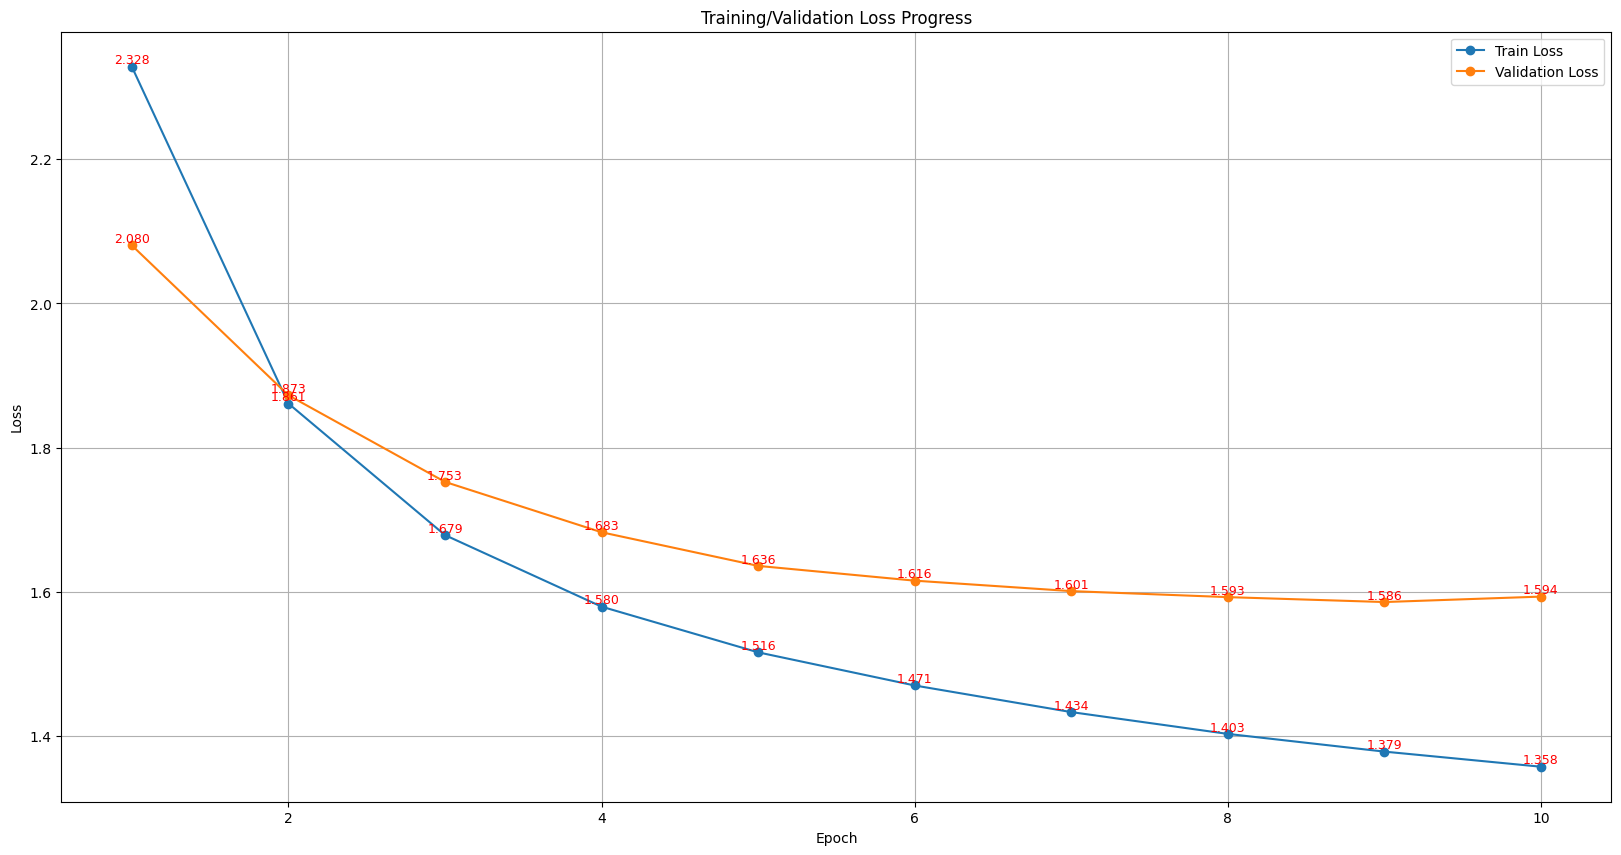

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) 

# Epochs starting from 1
x = [i + 1 for i in range(len(train_losses))]

# Plot training and validation losses
plt.plot(x, train_losses, marker='o', label='Train Loss')
plt.plot(x, val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation Loss Progress")
plt.legend()
plt.grid(True)

# Show values on each marker
for i, y in enumerate(train_losses):
    plt.text(x[i], y, f"{y:.3f}", ha='center', va='bottom', fontsize=9, color='red')
for i, y in enumerate(val_losses):
    plt.text(x[i], y, f"{y:.3f}", ha='center', va='bottom', fontsize=9, color='red')

plt.show()

torch.Size([1, 4, 18, 18])


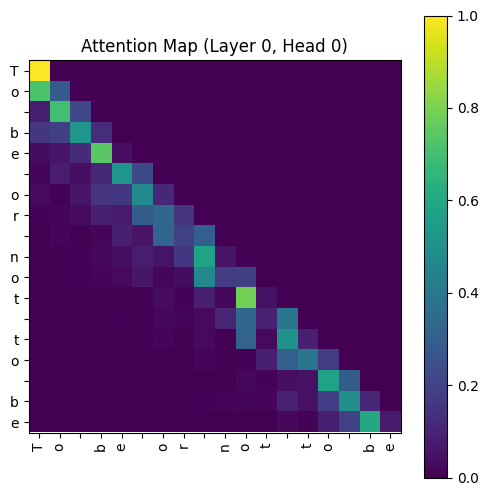

In [17]:
import matplotlib.pyplot as plt

def visualize_attention(model, text, stoi, itos, device="cpu", layer=0, head=0):
    
    model.eval()
    
    # Encode text
    input_ids = [stoi[c] for c in text]
    x = torch.tensor(input_ids).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, attn_maps = model(x)
    
    # Select layer & head
    attn = attn_maps[layer][0, head].cpu()  # [T, T]
    print(attn_maps[layer].shape)
    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(attn, cmap="viridis")
    plt.colorbar()
    
    tokens = list(text)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    
    plt.title(f"Attention Map (Layer {layer}, Head {head})")
    plt.show()

visualize_attention(
    model,
    text="To be or not to be",
    stoi=char_encode,
    itos=rev_char_encode,
    device=device,
    layer=0,
    head=0
)

<h1>6. Real Test</h1>
<h1>6.1 Loading Trained Weight</h1>

In [18]:
#model = VanillaRNN(vocab_size, embed_dim, hidden_dim)
model.load_state_dict(torch.load("/kaggle/working/best_transformer.pth", map_location=device))
model = model.to(device)
model.eval()

DecoderOnlyTransformer(
  (token_emb): Embedding(65, 256)
  (pos_enc): PositionalEncoding()
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (attention): ScaledDotProductAttention()
        (fc_out): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
    )
  )
  (fc_out): Linear(in_features=256, out_features=65, bias=True)
)

In [19]:
def generate_text(model, start_text, stoi, itos, max_len=200, temperature=0.8, context_size=128, device="cpu"):
    
    model.eval()
    
    input_ids = [stoi[c] for c in start_text]
    x = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    generated = start_text
    
    for _ in range(max_len):
        
        x = x[:, -context_size:]
        
        logits, _ = model(x)
        logits = logits[:, -1, :]
        
        logits = logits / temperature
        probs = F.softmax(logits, dim=-1)
        
        next_id = torch.multinomial(probs, 1)
        next_token = next_id.item()
        
        generated += itos[next_token]
        
        x = torch.cat([x, next_id], dim=1)
    
    return generated

<h1>6.2. Starting Real Text Generate</h1>

In [20]:
text = generate_text(
    model,
    start_text="To be or not to be",
    stoi=char_encode,
    itos=rev_char_encode,
    max_len=2000,
    temperature=0.8,
    device=device
)

print(text)

To be or not to before a while, noble gone.

LADY GREY:
Where is the groum to-morrow aparish.

KING RICEG EG HARUME G E ENINILIO:
EG EDWARGO:
EEDWARGO:

S:

Sdwarareed ure Me CE:
Ho, Tho, nee ne 'dondonentenstw gore ceareadrear 's, t agenemave t ivered t'elo; akninont
Sandurese aneno mind t he a she, t t ure t ane: akinothe'soleakno adono ho mp 'e
Sh; h. 's, olld ar nolinixerendenolead thone the t umint at s 's.'d'se nemnowenoseakinoleeteeak


Woruck 'd mes a.s, mathes scarcche I mane akndo mane barurt andnntain.nonewilorure Roudubit
W




I's 'd I





Floned therithethoneashenUpunigearearee n at w f, y:
Bed,; n iouathelexawhoneandathethide he, ar, t, t, ard t t s: st utreathonea leno I'thikeeade'th.
Wh; antreaicend t, t th t. herere d me t I'do; maremieamefe




Heasowe akn bid an t thithenoonele mune uthe: tho sce t bly reaneritrnonene tintarepread: 'I'd


As, angreme ory, t. auke tarisidononeagothorelelllle mo 'd m: 's an 's an y t thatheanathewhananfumithothathy ?









Asd'd t